# Notebook 06 - Final Evaluation & Cross-Model Comparision

## Environment Setup and Configuration

This section initialises the environment, imports required libraries, and loads configuration paths for model outputs, predictions, and evaluation artifacts.

- Adds project root to system path for module imports
- Imports data handling, visualization, and utility libraries
- Loads evaluation metrics and statistical functions
- Imports file paths for baseline and transformer model results
- Configures global plotting style for consistency across visualizations
- Defines color schemes and line styles for model comparison plots

In [1]:
# Add project root directory to system path for module imports
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Core libraries for data handling and computation
import pandas as pd
import numpy as np

# Visualization library
import matplotlib.pyplot as plt

# For loading saved model predictions and objects
import pickle

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Statistical function for significance testing
from scipy.stats import chi2 as chi2_dist

# Evaluation metrics for model performance
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    brier_score_loss,f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

# Import calibration tools
from sklearn.calibration import calibration_curve

# Import file paths and configuration constants
from config import (
    BASELINE_RESULTS_CSV,
    DISTILBERT_RESULTS_CSV, PUBMEDBERT_RESULTS_CSV, BIOBERT_RESULTS_CSV,
    DISTILBERT_PREDS_PKL, PUBMEDBERT_PREDS_PKL, BIOBERT_PREDS_PKL,
    BEST_BASELINE_PKL, ALL_RESULTS_CSV,
    PLOTS_DIR, METRICS_DIR,
)

# Evaluation Results Output Directory Setup
EVALUATION_DIR = PLOTS_DIR / "evaluation_results"
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

# Set global plotting style for consistency across all figures
plt.rcParams.update({
    'figure.dpi':120,
    'axes.spines.top':False,
    'axes.spines.right':False,
    'font.size':11,
})

# Define color mapping for different models (used in plots)
MODEL_COLORS = {
    'Logistic Regression':'#A8C8E1',
    'Random Forest':'#F4B9BE',
    'Linear SVM':'#B5D5C5',
    'DistilBERT':'#2E86AB',
    'PubMedBERT':'#E84855',
    'BioBERT':'#2A9D8F',
}

# Define line styles for baseline vs transformer models
MODEL_LS = {
    'Logistic Regression':'--',
    'Random Forest':'--',
    'Linear SVM':'--',
    'DistilBERT':'-',
    'PubMedBERT':'-',
    'BioBERT':'-',
}

# Additional color palette for general visualizations
PALETTE = ['#2E86AB','#E84855','#F4A261','#2A9D8F','#8338EC']

## Loading Model Results and Predictions

This section consolidates model evaluation results and loads prediction outputs for further analysis.
- Combines baseline and transformer model results into a single dataframe
- Saves aggregated results for unified comparison
- Loads stored prediction outputs for each model
- Extracts test labels (shared across models due to fixed split)
- Displays test set size and class distribution

In [2]:
# Combine results from baseline and transformer models
all_results = pd.concat([
    pd.read_csv(BASELINE_RESULTS_CSV),
    pd.read_csv(DISTILBERT_RESULTS_CSV),
    pd.read_csv(PUBMEDBERT_RESULTS_CSV),
    pd.read_csv(BIOBERT_RESULTS_CSV),
], ignore_index=True)

# Save combined results
all_results.to_csv(ALL_RESULTS_CSV, index=False)

# Display number of models loaded
print(f'Models loaded: {len(all_results)}')

# Utility function to load pickle files
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Load prediction outputs for each model
db_preds = load_pkl(DISTILBERT_PREDS_PKL)
pm_preds = load_pkl(PUBMEDBERT_PREDS_PKL)
bb_preds = load_pkl(BIOBERT_PREDS_PKL)
bl_preds = load_pkl(BEST_BASELINE_PKL)

# Extract test labels (same across all models)
y_test = db_preds['y_test']

# Display test set statistics
print(f'Test set: {len(y_test):,}  |  '
      f'Positive: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Models loaded: 6
Test set: 3,610  |  Positive: 694 (19.2%)


## Results Table for Model Comparison

This section formats and displays key evaluation metrics across all models for direct comparison.

- Selects relevant performance metrics for reporting
- Formats results into a structured table
- Ensures consistent numeric precision for readability
- Outputs table suitable for inclusion in report (Table 2)

In [3]:
# Columns for reporting
cols = [
    'Model','Type','Accuracy','F1_Weighted',
    'Precision_Pos','Recall_Pos','F1_Pos','ROC_AUC','PR_AUC'
]

# Print formatted results table
print('\n' + '='*90)
print('  RESULTS TABLE  ')
print('='*90)

table = all_results[cols].to_string(
    index=False,
    float_format='{:.4f}'.format
)

print(table)

print('='*90)


  RESULTS TABLE  
              Model        Type  Accuracy  F1_Weighted  Precision_Pos  Recall_Pos  F1_Pos  ROC_AUC  PR_AUC
Logistic Regression    Baseline    0.6939       0.7199         0.3272      0.5605  0.4132   0.7021  0.3882
      Random Forest    Baseline    0.7008       0.7208         0.3126      0.4640  0.3735   0.6776  0.3744
         Linear SVM    Baseline    0.8108       0.7344         0.6667      0.0317  0.0605   0.6912  0.3666
         DistilBERT Transformer    0.6834       0.7121         0.3211      0.5807  0.4135   0.7043  0.4023
         PubMedBERT Transformer    0.6994       0.7248         0.3345      0.5692  0.4213   0.7113  0.3999
            BioBERT Transformer    0.6842       0.7112         0.3129      0.5375  0.3955   0.7000  0.3880


## ROC and Precision-Recall Curve Comparison

This section visualises model performance using ROC and Precision-Recall curves for both baseline and transformer models.

- Computes ROC and PR curves for the best baseline model
- Plots transformer model performance for comparison
- Uses consistent color and line styles to distinguish model types
- Includes random baseline and class imbalance reference
- Saves high-resolution plot for reporting and analysis

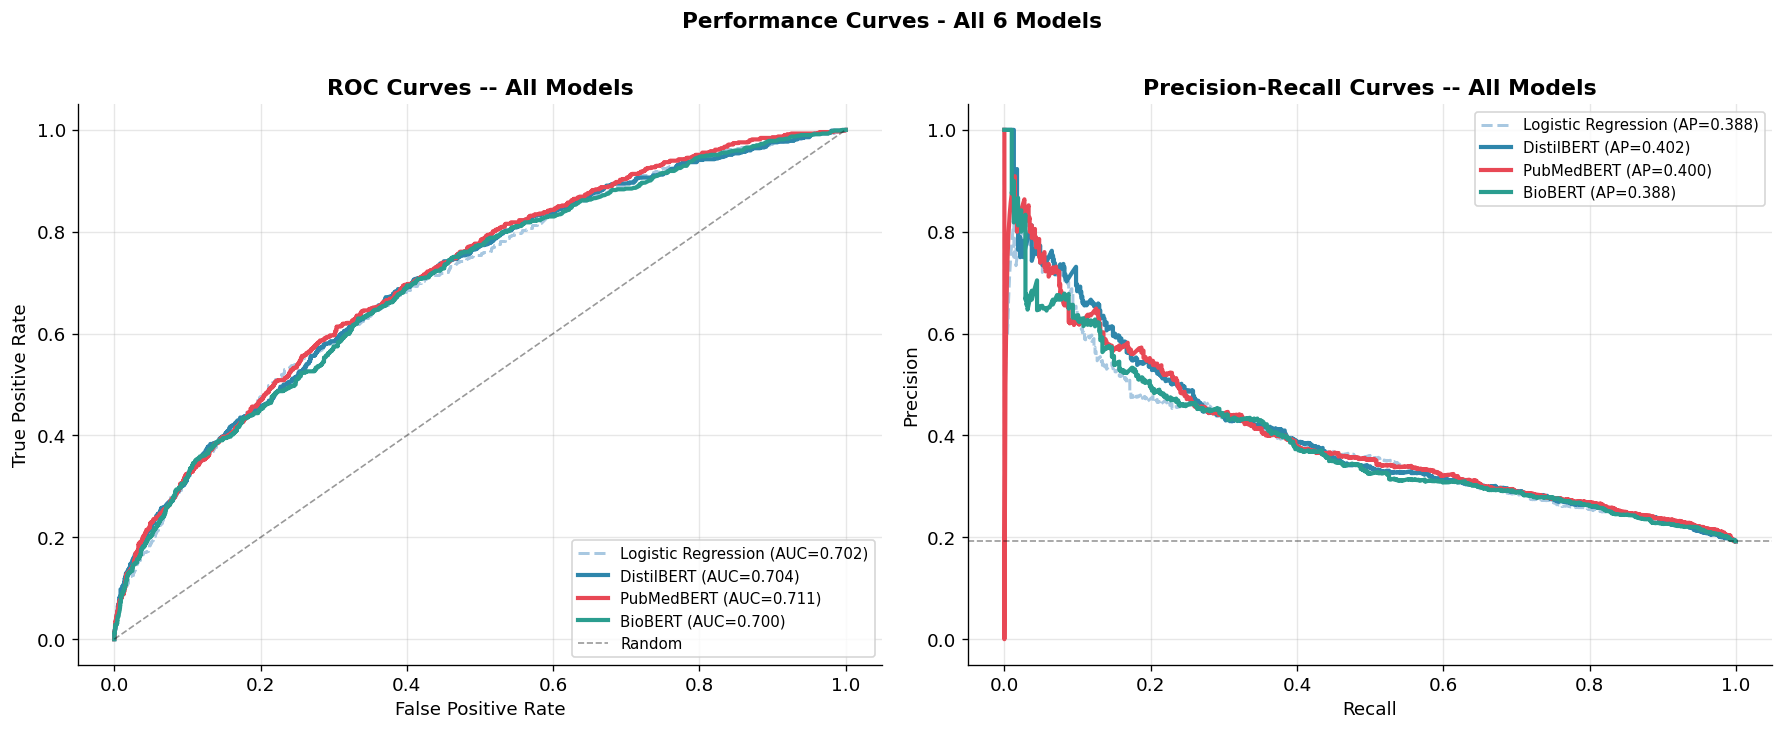

In [4]:
# Setup: model groups
TRANSFORMER_PREDS = [
    ('DistilBERT', db_preds),
    ('PubMedBERT', pm_preds),
    ('BioBERT', bb_preds),
]

# Figure initialisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Baseline model metrics
bl_name = bl_preds['name']
bl_probs = bl_preds['y_prob']

bl_fpr, bl_tpr, _ = roc_curve(y_test, bl_probs)
bl_prec, bl_rec, _ = precision_recall_curve(y_test, bl_probs)

bl_roc = roc_auc_score(y_test, bl_probs)
bl_pr = average_precision_score(y_test, bl_probs)

# Plot baseline
axes[0].plot(
    bl_fpr, bl_tpr,
    color=MODEL_COLORS.get(bl_name,'grey'),
    ls='--', lw=1.8,
    label=f'{bl_name} (AUC={bl_roc:.3f})'
)

axes[1].plot(
    bl_rec, bl_prec,
    color=MODEL_COLORS.get(bl_name,'grey'),
    ls='--', lw=1.8,
    label=f'{bl_name} (AP={bl_pr:.3f})'
)

# Transformer models
for name, preds in TRANSFORMER_PREDS:
    probs = preds['y_prob']

    fpr, tpr, _ = roc_curve(y_test, probs)
    prec, rec, _ = precision_recall_curve(y_test, probs)

    axes[0].plot(
        fpr, tpr,
        color=MODEL_COLORS[name],
        ls='-', lw=2.5,
        label=f'{name} (AUC={preds["roc_auc"]:.3f})'
    )

    axes[1].plot(
        rec, prec,
        color=MODEL_COLORS[name],
        ls='-', lw=2.5,
        label=f'{name} (AP={preds["pr_auc"]:.3f})'
    )

# Plot formatting
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
axes[0].set_title('ROC Curves -- All Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, alpha=0.4)
axes[1].set_title('Precision-Recall Curves -- All Models', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3)

# Save and display
plt.suptitle(
    'Performance Curves - All 6 Models',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_01_combined_roc_pr.png',
    dpi=150, bbox_inches='tight'
)

plt.show()

## Model Comparison using Key Metrics

This section compares model performance across selected evaluation metrics using a grouped bar chart.

- Selects key metrics relevant for classification performance
- Organises models into baseline and transformer groups
- Extracts metric values for each model in consistent order
- Visualises comparisons using grouped bars for interpretability
- Highlights separation between baseline and transformer models

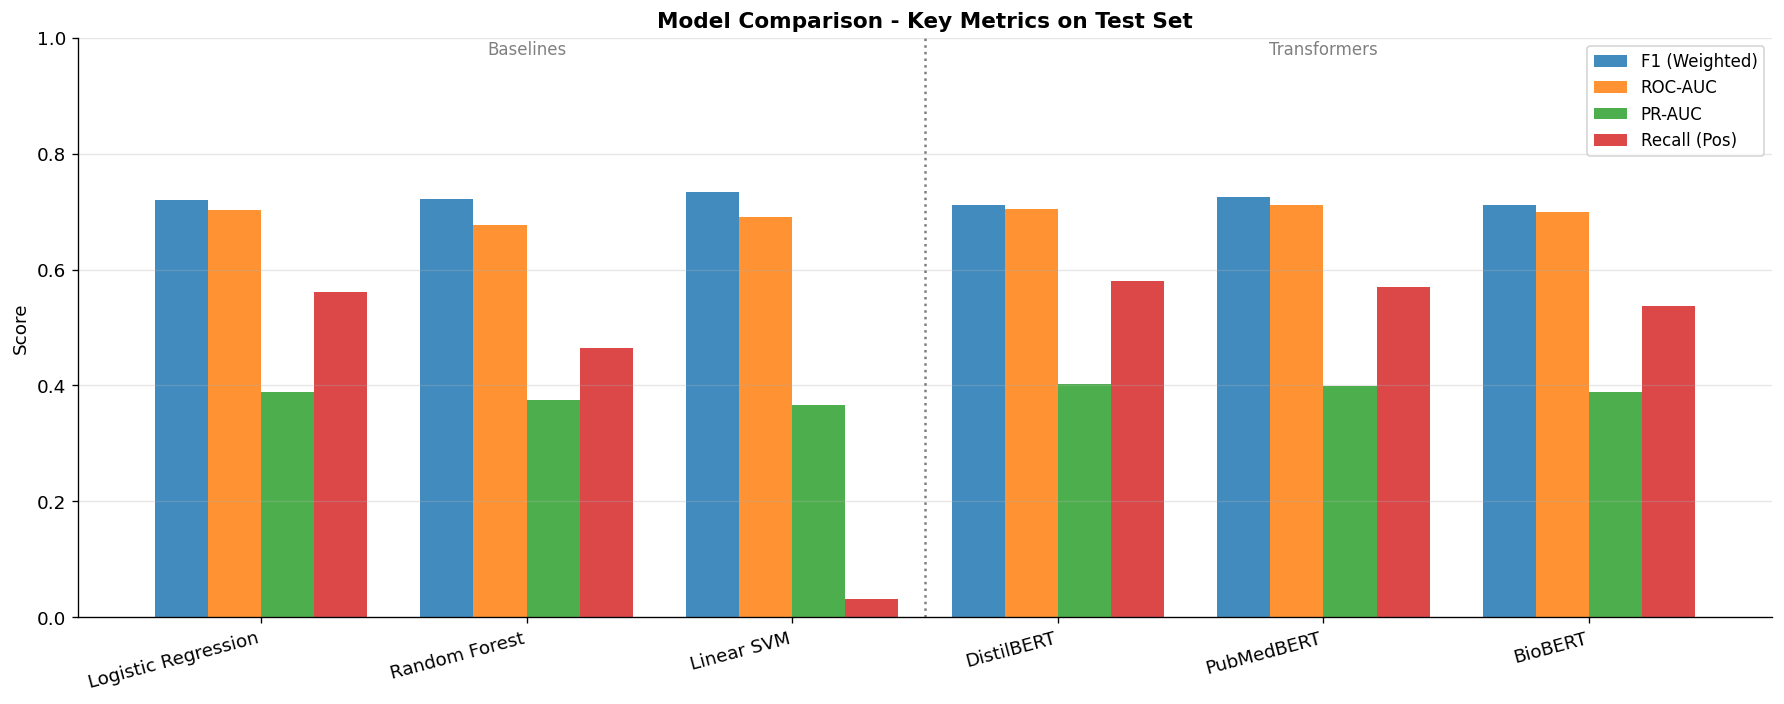

In [5]:
# Metrics and labels
metrics_show = ['F1_Weighted','ROC_AUC','PR_AUC','Recall_Pos']
metric_labels = ['F1 (Weighted)','ROC-AUC','PR-AUC','Recall (Pos)']

# Model order for consistent plotting
model_order = [
    'Logistic Regression','Random Forest','Linear SVM',
    'DistilBERT','PubMedBERT','BioBERT'
]

# X-axis setup
x = np.arange(len(model_order))
width = 0.2

# Create figure
fig, ax = plt.subplots(figsize=(15, 6))


# Extract and plot metrics
for i, (metric, label) in enumerate(zip(metrics_show, metric_labels)):
    vals = []

    for m in model_order:
        row = all_results[all_results['Model'] == m]
        vals.append(float(row[metric].values[0]) if len(row) else 0)

    ax.bar(
        x + (i - 1.5) * width,
        vals,
        width,
        label=label,
        alpha=0.85
    )

# Visual separation between model groups
ax.axvline(x=2.5, color='black', linestyle=':', lw=1.5, alpha=0.5)

ax.text(
    1.0, 0.97, 'Baselines',
    ha='center', fontsize=10,
    color='grey',
    transform=ax.get_xaxis_transform()
)

ax.text(
    4.0, 0.97, 'Transformers',
    ha='center', fontsize=10,
    color='grey',
    transform=ax.get_xaxis_transform()
)

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha='right')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')

ax.set_title(
    'Model Comparison - Key Metrics on Test Set',
    fontweight='bold', fontsize=13
)

ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# Save and display
plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_02_model_comparison_bars.png',
    dpi=150, bbox_inches='tight'
)

plt.show()

## Confusion Matrix Analysis for Transformer Models

This section visualises confusion matrices for transformer-based models to analyse classification performance in detail.

- Computes confusion matrices for each transformer model
- Derives sensitivity and specificity from confusion matrix values
- Visualises class-wise prediction performance
- Provides insight into false positives and false negatives
- Saves plots for reporting and qualitative evaluation

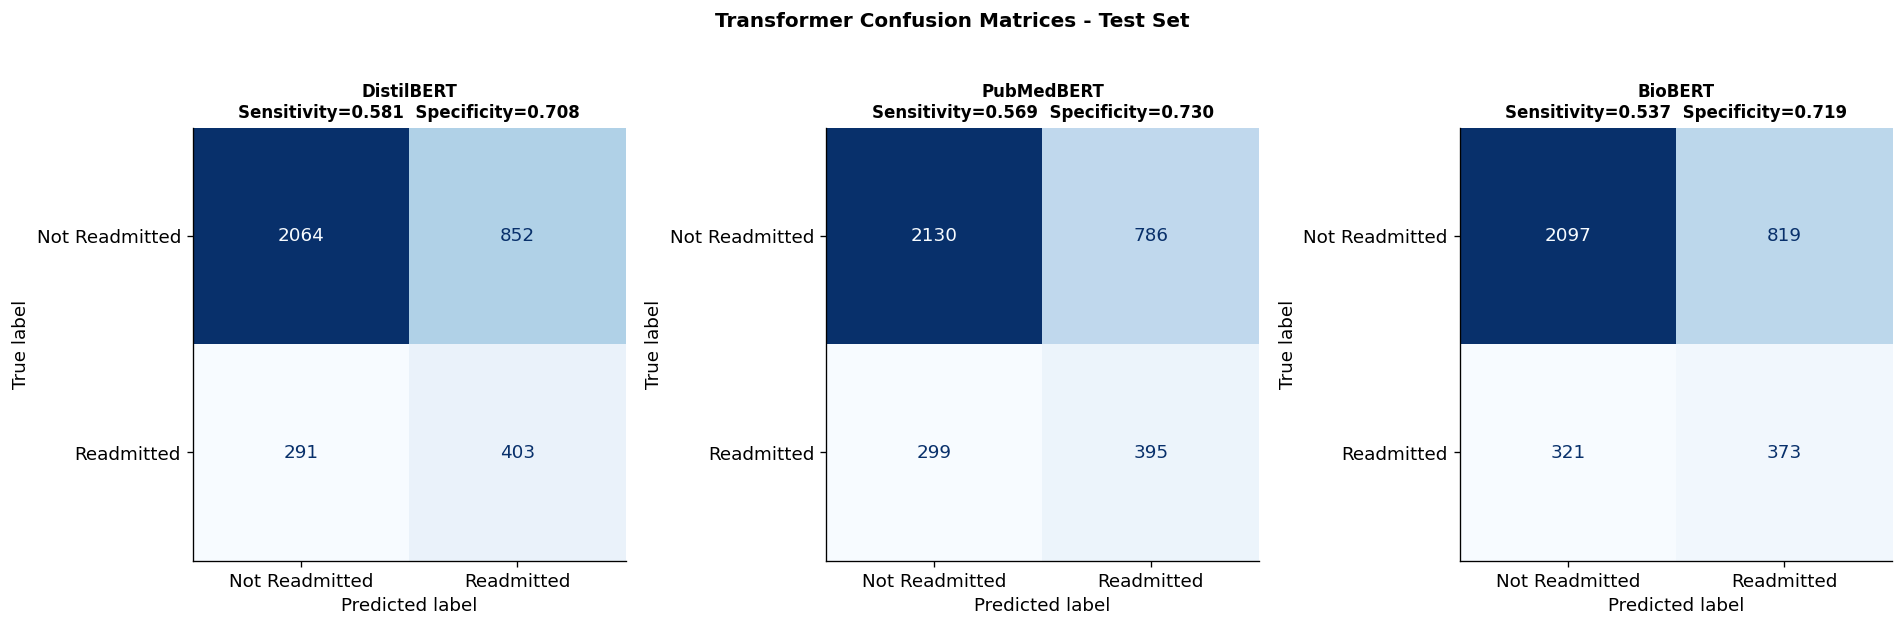

In [6]:
# Create subplots for confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot confusion matrices for transformer models
for ax, (name, preds) in zip(axes, TRANSFORMER_PREDS):
    cm = confusion_matrix(y_test, preds['y_pred'])

    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    ConfusionMatrixDisplay(
        cm,
        display_labels=['Not Readmitted','Readmitted']
    ).plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f'{name}\nSensitivity={sens:.3f}  Specificity={spec:.3f}',
        fontweight='bold',
        fontsize=10
    )

# Save and display
plt.suptitle(
    'Transformer Confusion Matrices - Test Set',
    fontsize=12,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_03_transformer_confusion_matrices.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Error Analysis: False Positives vs False Negatives

This section analyses model errors by comparing true/false predictions across transformer models.

- Computes confusion matrix components for each model
- Breaks down predictions into TP, FP, TN, and FN counts
- Visualises error distribution using bar charts
- Highlights the impact of false negatives in a clinical context
- Emphasises recall as a critical metric for deployment

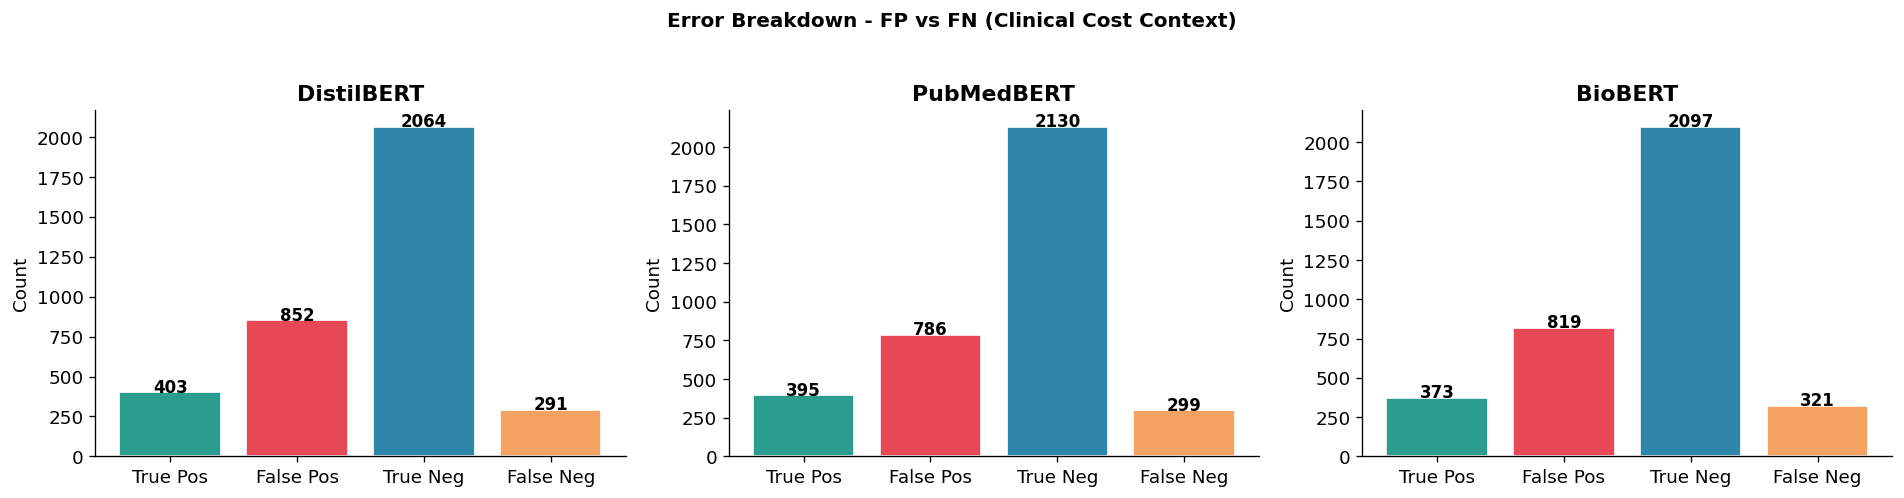

In [7]:
# Create subplots for error analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Define colors for error categories
error_colors = ['#2A9D8F','#E84855','#2E86AB','#F4A261']

# Plot error breakdown for each transformer model
for ax, (name, preds) in zip(axes, TRANSFORMER_PREDS):
    cm = confusion_matrix(y_test, preds['y_pred'])

    tn, fp, fn, tp = cm.ravel()

    vals = [tp, fp, tn, fn]
    labels = ['True Pos','False Pos','True Neg','False Neg']

    bars = ax.bar(
        labels,
        vals,
        color=error_colors,
        edgecolor='white'
    )

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(v),
            ha='center',
            fontweight='bold',
            fontsize=10
        )

    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')

# Save and display
plt.suptitle(
    'Error Breakdown - FP vs FN (Clinical Cost Context)',
    fontsize=12,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_04_error_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Statistical Significance Testing using McNemar's Test

This section evaluates whether performance differences between models are statistically significant.

- Implements McNemar’s test to compare paired model predictions
- Measures disagreement in prediction errors between two models
- Computes chi-square statistic and corresponding p-value
- Interprets statistical significance using standard thresholds
- Compares best transformer against baseline and across transformers

In [8]:
# McNemar test implementation
def mcnemar(y_true, pred_a, pred_b, name_a, name_b):
    b = np.sum((pred_a != y_true) & (pred_b == y_true))
    c = np.sum((pred_a == y_true) & (pred_b != y_true))

    if (b + c) == 0:
        chi2, p = 0.0, 1.0
    else:
        chi2 = (abs(b - c) - 1)**2 / (b + c)
        p = 1 - chi2_dist.cdf(chi2, df=1)

    sig = (
        '*** p<0.001' if p < 0.001 else
        '** p<0.01'  if p < 0.01  else
        '* p<0.05'   if p < 0.05  else
        'n.s.'
    )

    print(f'{name_a:<20} vs {name_b:<20}  chi2={chi2:.3f}  p={p:.4f}  {sig}')

# Run statistical comparisons
print("McNemar's Tests (H0: same error rate):")
print('-' * 70)


# Identify best transformer model based on ROC-AUC
best_t = all_results[
    all_results['Type'] == 'Transformer'
].sort_values('ROC_AUC', ascending=False).iloc[0]['Model']

best_t_preds = {
    'DistilBERT': db_preds,
    'PubMedBERT': pm_preds,
    'BioBERT': bb_preds
}[best_t]

# Comparisons
mcnemar(y_test, bl_preds['y_pred'], best_t_preds['y_pred'], bl_name, best_t)

mcnemar(y_test, db_preds['y_pred'], pm_preds['y_pred'],
        'DistilBERT','PubMedBERT')

mcnemar(y_test, db_preds['y_pred'], bb_preds['y_pred'],
        'DistilBERT','BioBERT')

mcnemar(y_test, pm_preds['y_pred'], bb_preds['y_pred'],
        'PubMedBERT','BioBERT')

McNemar's Tests (H0: same error rate):
----------------------------------------------------------------------
Logistic Regression  vs PubMedBERT            chi2=0.531  p=0.4662  n.s.
DistilBERT           vs PubMedBERT            chi2=5.470  p=0.0193  * p<0.05
DistilBERT           vs BioBERT               chi2=0.007  p=0.9355  n.s.
PubMedBERT           vs BioBERT               chi2=4.346  p=0.0371  * p<0.05


## Radar Chart Comparison for Transformer Models

This section visualises multi-metric performance of transformer models using a radar chart.

- Selects key evaluation metrics for holistic comparison
- Normalises all metrics to a common scale (0–1)
- Plots each transformer model across all metrics
- Highlights strengths and trade-offs between models
- Provides an intuitive visual summary of model performance

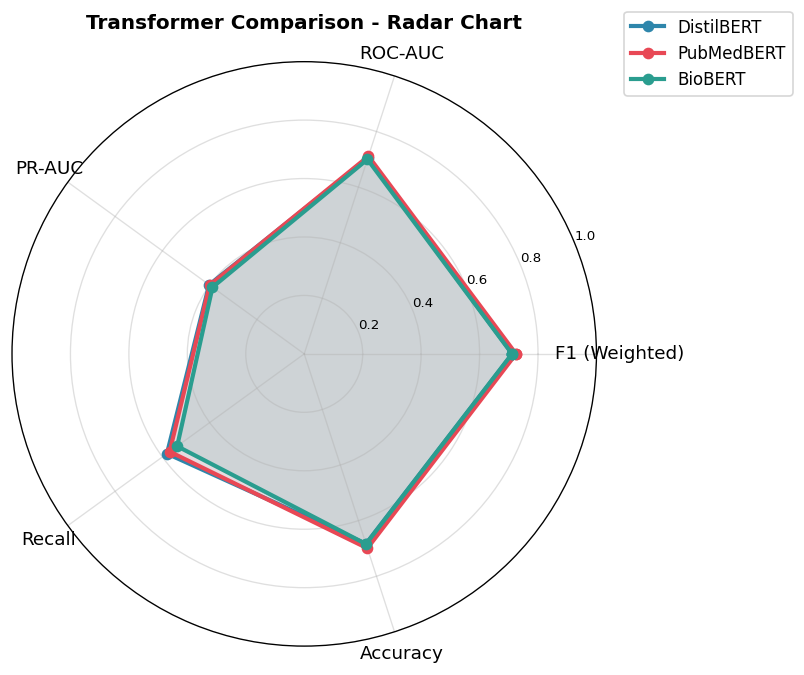

In [9]:
# Metrics and labels for radar chart
metrics_radar = ['F1_Weighted','ROC_AUC','PR_AUC','Recall_Pos','Accuracy']
labels_radar = ['F1 (Weighted)','ROC-AUC','PR-AUC','Recall','Accuracy']

# Transformer models and colors
t_names = ['DistilBERT','PubMedBERT','BioBERT']
t_colors = ['#2E86AB','#E84855','#2A9D8F']

# Angle setup for radar chart
N = len(metrics_radar)

theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
theta = np.concatenate([theta, [theta[0]]])

# Create polar plot
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Plot each transformer model
for name, color in zip(t_names, t_colors):
    row = all_results[all_results['Model'] == name].iloc[0]

    vals = [float(row[m]) for m in metrics_radar]
    vals = vals + [vals[0]]

    ax.plot(
        theta, vals,
        'o-', lw=2.5,
        color=color,
        label=name,
        markersize=6
    )

    ax.fill(
        theta, vals,
        alpha=0.12,
        color=color
    )

# Axis formatting
ax.set_xticks(theta[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)

ax.set_ylim(0, 1)

ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)

ax.set_title(
    'Transformer Comparison - Radar Chart',
    fontweight='bold',
    pad=20,
    fontsize=12
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.1),
    fontsize=10
)

ax.grid(True, alpha=0.4)

# Save and display
plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_05_radar_chart.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Threshold Optimisation Analysis (PubMedBERT)
This section evaluates the impact of classification threshold selection on model performance.
- Sweeps probability thresholds to analyse Precision, Recall, and F1 trade-offs
- Identifies threshold that maximises F1-score
- Determines clinically relevant threshold prioritising Recall (≥ 0.60)
- Compares default threshold (0.50) with optimised thresholds
- Highlights importance of threshold tuning in imbalanced clinical settings

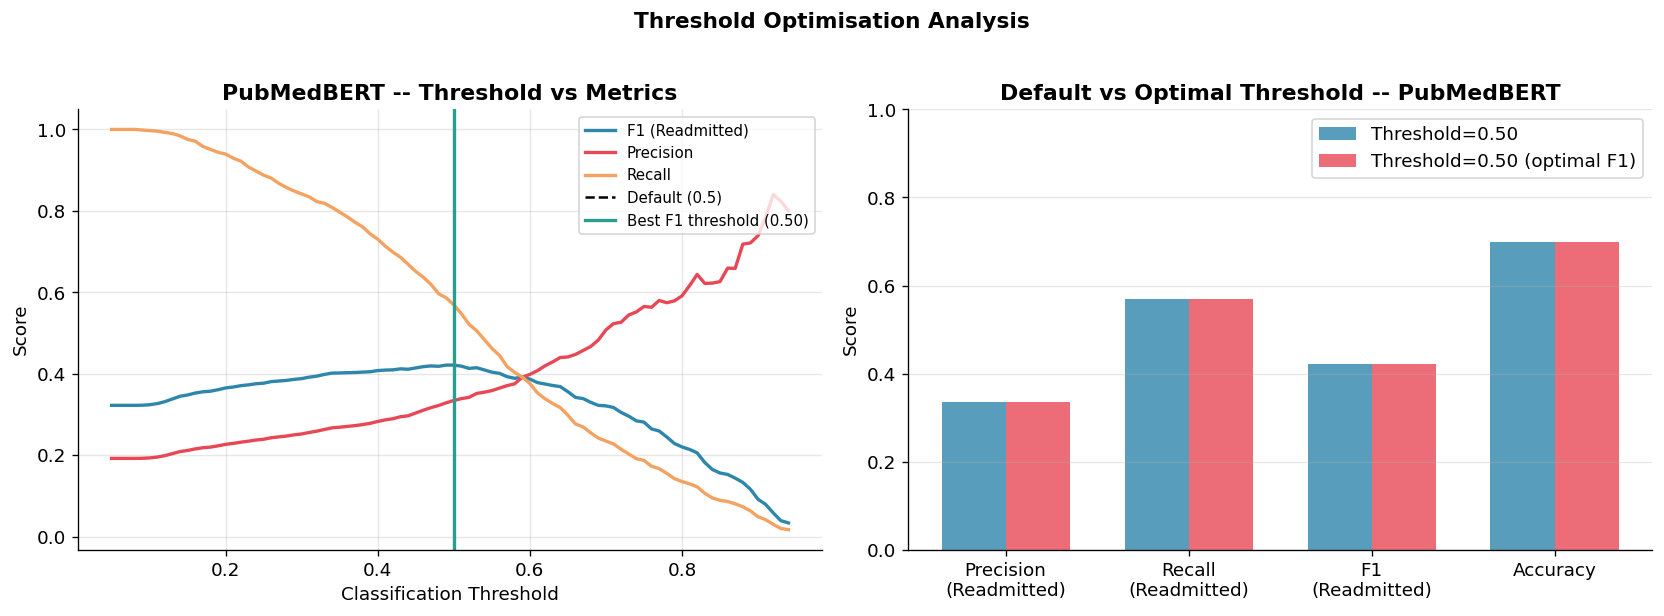

=== Threshold Optimisation -- PubMedBERT ===

  Default threshold (0.50):
    Precision : 0.3345
    Recall    : 0.5692
    F1        : 0.4213

  Optimal F1 threshold (0.50):
    Precision : 0.3345
    Recall    : 0.5692
    F1        : 0.4213

  Clinical threshold (Recall>=0.60): 0.47
    Precision : 0.3169
    Recall    : 0.6196
    F1        : 0.4193


In [10]:
# Extract probabilities
pm_prob = pm_preds['y_prob']

# Threshold sweep
thresholds = np.arange(0.05, 0.95, 0.01)

f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    preds_t = (pm_prob >= t).astype(int)

    rep_t = classification_report(
        y_test, preds_t,
        output_dict=True,
        zero_division=0
    )

    f1_scores.append(rep_t['1']['f1-score'])
    precisions.append(rep_t['1']['precision'])
    recalls.append(rep_t['1']['recall'])


# Convert to arrays
f1_scores = np.array(f1_scores)
precisions = np.array(precisions)
recalls = np.array(recalls)

# Best F1 threshold
best_f1_idx = np.argmax(f1_scores)
best_f1_t = thresholds[best_f1_idx]

# Best threshold for Recall >= 0.60
recall_mask = recalls >= 0.60

if recall_mask.any():
    best_rec_idx = np.argmax(precisions * recall_mask)
    best_rec_t = thresholds[best_rec_idx]
else:
    best_rec_t = None

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot threshold vs metrics
axes[0].plot(thresholds, f1_scores,  color=PALETTE[0], lw=2, label='F1 (Readmitted)')
axes[0].plot(thresholds, precisions, color=PALETTE[1], lw=2, label='Precision')
axes[0].plot(thresholds, recalls,    color=PALETTE[2], lw=2, label='Recall')

axes[0].axvline(0.5, color='k', linestyle='--', lw=1.5, label='Default (0.5)')
axes[0].axvline(best_f1_t, color=PALETTE[3], linestyle='-', lw=2,
                label=f'Best F1 threshold ({best_f1_t:.2f})')

axes[0].set_title('PubMedBERT -- Threshold vs Metrics', fontweight='bold')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Default vs optimal comparison
default_pred = (pm_prob >= 0.50).astype(int)
optimal_pred = (pm_prob >= best_f1_t).astype(int)

default_rep = classification_report(y_test, default_pred, output_dict=True, zero_division=0)
optimal_rep = classification_report(y_test, optimal_pred, output_dict=True, zero_division=0)

# Prepare comparison values
categories = [
    'Precision\n(Readmitted)',
    'Recall\n(Readmitted)',
    'F1\n(Readmitted)',
    'Accuracy'
]

default_vals = [
    default_rep['1']['precision'],
    default_rep['1']['recall'],
    default_rep['1']['f1-score'],
    default_rep['accuracy'],
]

optimal_vals = [
    optimal_rep['1']['precision'],
    optimal_rep['1']['recall'],
    optimal_rep['1']['f1-score'],
    optimal_rep['accuracy'],
]

# Bar plot comparison
x = np.arange(len(categories))
w = 0.35

axes[1].bar(
    x - w/2, default_vals, w,
    label='Threshold=0.50',
    color=PALETTE[0],
    alpha=0.8
)

axes[1].bar(
    x + w/2, optimal_vals, w,
    label=f'Threshold={best_f1_t:.2f} (optimal F1)',
    color=PALETTE[1],
    alpha=0.8
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)

axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Score')

axes[1].set_title(
    'Default vs Optimal Threshold -- PubMedBERT',
    fontweight='bold'
)

axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

# Save and display
plt.suptitle(
    'Threshold Optimisation Analysis',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_06_threshold_optimisation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary output
print('=== Threshold Optimisation -- PubMedBERT ===')

print('\n  Default threshold (0.50):')
print(f'    Precision : {default_rep["1"]["precision"]:.4f}')
print(f'    Recall    : {default_rep["1"]["recall"]:.4f}')
print(f'    F1        : {default_rep["1"]["f1-score"]:.4f}')

print(f'\n  Optimal F1 threshold ({best_f1_t:.2f}):')
print(f'    Precision : {optimal_rep["1"]["precision"]:.4f}')
print(f'    Recall    : {optimal_rep["1"]["recall"]:.4f}')
print(f'    F1        : {optimal_rep["1"]["f1-score"]:.4f}')

if best_rec_t:
    print(f'\n  Clinical threshold (Recall>=0.60): {best_rec_t:.2f}')

    clinical_pred = (pm_prob >= best_rec_t).astype(int)
    clin_rep = classification_report(
        y_test,
        clinical_pred,
        output_dict=True,
        zero_division=0
    )

    print(f'    Precision : {clin_rep["1"]["precision"]:.4f}')
    print(f'    Recall    : {clin_rep["1"]["recall"]:.4f}')
    print(f'    F1        : {clin_rep["1"]["f1-score"]:.4f}')

## Calibration Analysis (Reliability Diagram and Brier Score)

This section evaluates how well predicted probabilities reflect true outcome likelihoods.

- Assesses probability calibration using reliability diagrams
- Compares predicted probabilities with observed frequencies
- Computes Brier score as a measure of calibration quality
- Benchmarks models against a no-skill baseline
- Determines whether predicted probabilities are suitable for clinical decision-making

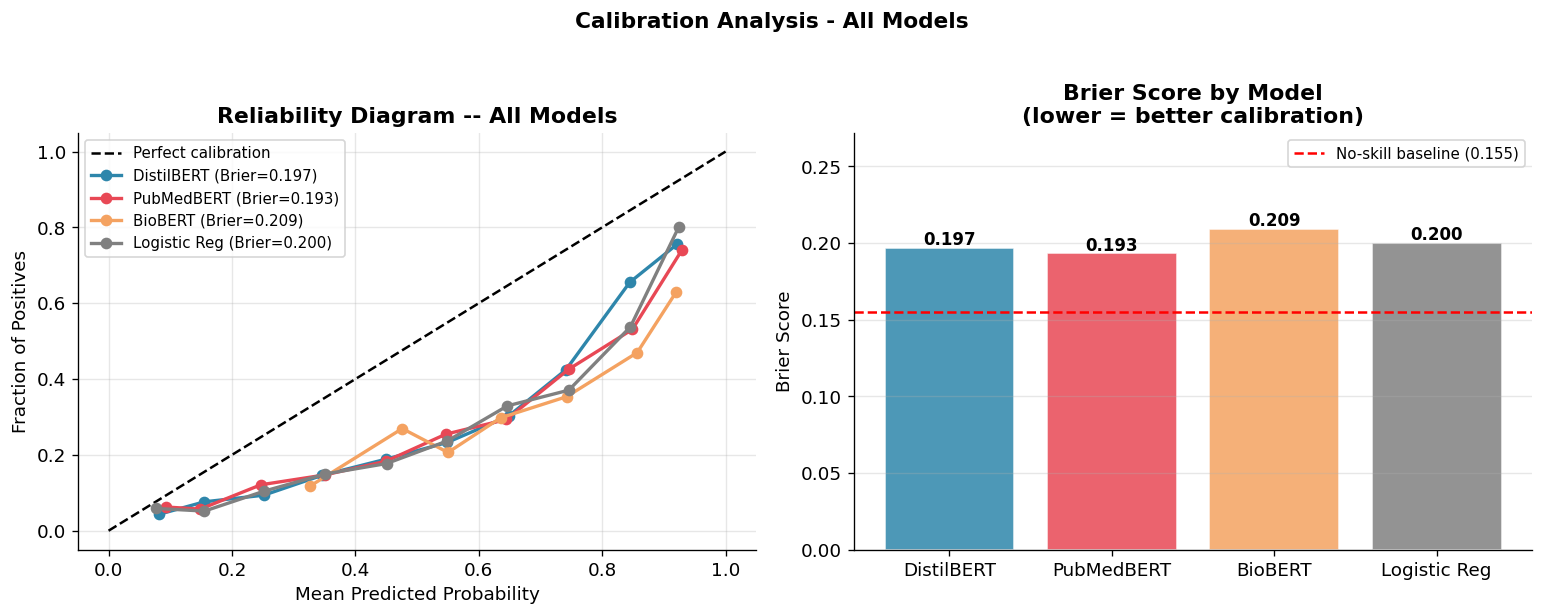

=== Calibration - Brier Scores (lower = better) ===
  DistilBERT           : 0.1969
  PubMedBERT           : 0.1933
  BioBERT              : 0.2093
  Logistic Reg         : 0.2004
  No-skill baseline    : 0.1553

  -> Brier score < 0.155 means the model adds value over naive prediction.


In [11]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Model probabilities
model_probs = [
    ('DistilBERT', db_preds['y_prob'], PALETTE[0]),
    ('PubMedBERT', pm_preds['y_prob'], PALETTE[1]),
    ('BioBERT', bb_preds['y_prob'], PALETTE[2]),
    ('Logistic Reg', bl_preds['y_prob'], 'grey'),
]

# Reliability diagram
axes[0].plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')

for name, probs, color in model_probs:
    fraction_pos, mean_pred = calibration_curve(
        y_test, probs,
        n_bins=10,
        strategy='uniform'
    )

    brier = brier_score_loss(y_test, probs)

    axes[0].plot(
        mean_pred, fraction_pos,
        'o-',
        color=color,
        lw=2,
        markersize=6,
        label=f'{name} (Brier={brier:.3f})'
    )

axes[0].set_title('Reliability Diagram -- All Models', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)


# Brier score bar chart
names = [m[0] for m in model_probs]
briers = [brier_score_loss(y_test, m[1]) for m in model_probs]
colors = [m[2] for m in model_probs]

bars = axes[1].bar(
    names,
    briers,
    color=colors,
    edgecolor='white',
    alpha=0.85
)

for bar, val in zip(bars, briers):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

# No-skill baseline
baseline_brier = brier_score_loss(
    y_test,
    np.full_like(y_test, y_test.mean(), dtype=float)
)

axes[1].axhline(
    baseline_brier,
    color='red',
    linestyle='--',
    lw=1.5,
    label=f'No-skill baseline ({baseline_brier:.3f})'
)

axes[1].set_title(
    'Brier Score by Model\n(lower = better calibration)',
    fontweight='bold'
)

axes[1].set_ylabel('Brier Score')
axes[1].set_ylim(0, max(briers) * 1.3)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

# Save and display
plt.suptitle(
    'Calibration Analysis - All Models',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_07_calibration.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary output
print('=== Calibration - Brier Scores (lower = better) ===')

for name, probs, _ in model_probs:
    bs = brier_score_loss(y_test, probs)
    print(f'  {name:<20} : {bs:.4f}')

print(f'  {"No-skill baseline":<20} : {baseline_brier:.4f}')

print(f'\n  -> Brier score < {baseline_brier:.3f} means the model adds value over naive prediction.')

## Final Evaluation Summary

This section presents a consolidated summary of model performance and highlights the best-performing models.

- Displays key evaluation metrics for all models
- Identifies best overall model based on ROC-AUC
- Identifies best baseline model for comparison
- Computes performance uplift achieved by transformer models
- Provides paths to saved figures and metrics for reporting

In [12]:
# Print summary header
print('=' * 70)
print('  FINAL EVALUATION SUMMARY')
print('=' * 70)

# Columns for summary
cols_summary = [
    'Model','Type',
    'F1_Weighted','ROC_AUC','PR_AUC','Recall_Pos'
]

summary_table = all_results[cols_summary].to_string(
    index=False,
    float_format='{:.4f}'.format
)

print(summary_table)

# Identify best models
best_all = all_results.loc[all_results['ROC_AUC'].idxmax()]

baseline_df = all_results[all_results['Type'] == 'Baseline']
best_bl = baseline_df.loc[baseline_df['ROC_AUC'].idxmax()]

# Print best model comparison
print(f'\n  Best overall    : {best_all["Model"]}  (ROC-AUC={best_all["ROC_AUC"]:.4f})')
print(f'  Best baseline   : {best_bl["Model"]}  (ROC-AUC={best_bl["ROC_AUC"]:.4f})')

uplift = best_all['ROC_AUC'] - best_bl['ROC_AUC']

print(f'  Uplift          : +{uplift:.4f} ROC-AUC')

print('=' * 70)

  FINAL EVALUATION SUMMARY
              Model        Type  F1_Weighted  ROC_AUC  PR_AUC  Recall_Pos
Logistic Regression    Baseline       0.7199   0.7021  0.3882      0.5605
      Random Forest    Baseline       0.7208   0.6776  0.3744      0.4640
         Linear SVM    Baseline       0.7344   0.6912  0.3666      0.0317
         DistilBERT Transformer       0.7121   0.7043  0.4023      0.5807
         PubMedBERT Transformer       0.7248   0.7113  0.3999      0.5692
            BioBERT Transformer       0.7112   0.7000  0.3880      0.5375

  Best overall    : PubMedBERT  (ROC-AUC=0.7113)
  Best baseline   : Logistic Regression  (ROC-AUC=0.7021)
  Uplift          : +0.0093 ROC-AUC
